In [86]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings("ignore")

In [87]:
from sklearn.datasets import fetch_california_housing

In [88]:
data = fetch_california_housing()

In [89]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [90]:
data.feature_names


['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [91]:
df = pd.DataFrame(data.data,columns=data.feature_names)

In [92]:
df["price"] = data.target

In [93]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [94]:
# multicolliniearty --> means one feature is explained by other features (more than one features)

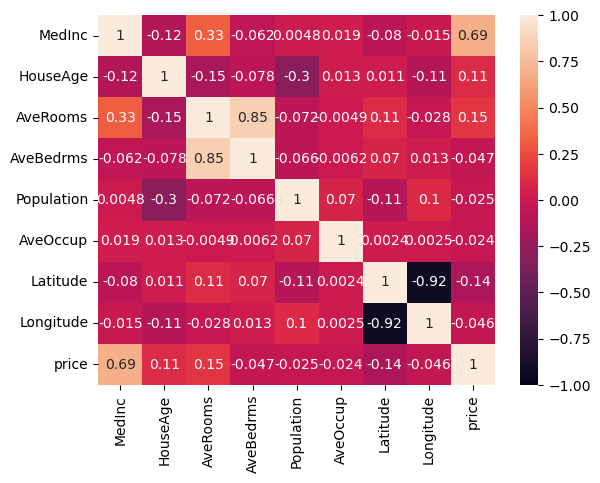

In [95]:
sns.heatmap(df.corr(),annot=True,vmin=-1,vmax=1) # annot = True means to get the corr value
plt.show() 

<Figure size 300x400 with 0 Axes>

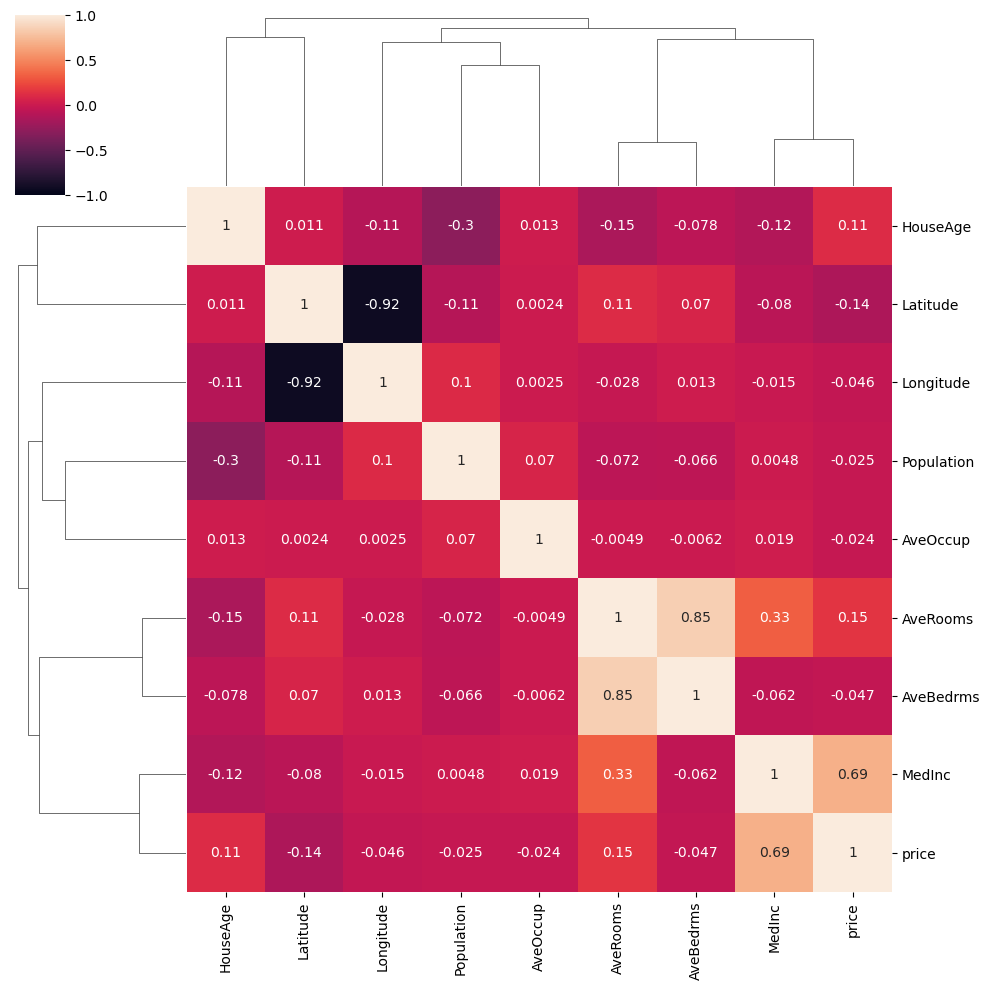

In [96]:
plt.figure(figsize=(3,4))
sns.clustermap(df.corr(),annot= True,vmin=-1,vmax=1)

In [97]:
# problem with the above graph --> u understand the relationship between features 

In [98]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [99]:
vif = pd.DataFrame()
vif["features"] = df.columns


In [100]:
vif["VIF"] = [variance_inflation_factor(df.values,i)for i in range(len(df.columns))]

In [101]:
vif  # if vif is >10 drop the value one by one here longitude drop and calculate again vif

,features,VIF
0,MedInc,19.624998
1,HouseAge,7.592663
2,AveRooms,47.956351
3,AveBedrms,45.358192
4,Population,2.936078
5,AveOccup,1.099530
6,Latitude,568.497332
7,Longitude,640.064211
8,price,9.285659


In [102]:
df1 = df.copy()

In [103]:
df1.drop("Longitude",axis=1,inplace=True)

In [104]:
df1

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,3.422
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,0.847


In [105]:
vif = pd.DataFrame()
vif["features"] = df1.columns
vif["VIF"] = [variance_inflation_factor(df1.values,i)for i in range(len(df1.columns))]

In [106]:
vif  # drop avg room 

,features,VIF
0,MedInc,18.639889
1,HouseAge,7.346583
2,AveRooms,44.714760
3,AveBedrms,42.072000
4,Population,2.796280
5,AveOccup,1.099394
6,Latitude,22.873934
7,price,9.193500


In [107]:
df1.drop("AveRooms",axis=1,inplace=True)

In [108]:
df1

,MedInc,HouseAge,AveBedrms,Population,AveOccup,Latitude,price
0,8.3252,41.0,1.023810,322.0,2.555556,37.88,4.526
1,8.3014,21.0,0.971880,2401.0,2.109842,37.86,3.585
2,7.2574,52.0,1.073446,496.0,2.802260,37.85,3.521
3,5.6431,52.0,1.073059,558.0,2.547945,37.85,3.413
4,3.8462,52.0,1.081081,565.0,2.181467,37.85,3.422
...,...,...,...,...,...,...,...
20635,1.5603,25.0,1.133333,845.0,2.560606,39.48,0.781
20636,2.5568,18.0,1.315789,356.0,3.122807,39.49,0.771
20637,1.7000,17.0,1.120092,1007.0,2.325635,39.43,0.923
20638,1.8672,18.0,1.171920,741.0,2.123209,39.43,0.847


In [109]:
vif = pd.DataFrame()
vif["features"] = df1.columns
vif["VIF"] = [variance_inflation_factor(df1.values,i)for i in range(len(df1.columns))]

In [110]:
vif

,features,VIF
0,MedInc,10.584081
1,HouseAge,7.260588
2,AveBedrms,6.440667
3,Population,2.762794
4,AveOccup,1.098719
5,Latitude,22.094483
6,price,8.674858


In [111]:
df1.drop("Latitude",axis=1,inplace=True)

In [112]:
vif = pd.DataFrame()
vif["features"] = df1.columns
vif["VIF"] = [variance_inflation_factor(df1.values,i)for i in range(len(df1.columns))]

In [114]:
vif

,features,VIF
0,MedInc,8.855104
1,HouseAge,4.156145
2,AveBedrms,4.264253
3,Population,2.223926
4,AveOccup,1.098671
5,price,8.607339


In [116]:
df1

,MedInc,HouseAge,AveBedrms,Population,AveOccup,price
0,8.3252,41.0,1.023810,322.0,2.555556,4.526
1,8.3014,21.0,0.971880,2401.0,2.109842,3.585
2,7.2574,52.0,1.073446,496.0,2.802260,3.521
3,5.6431,52.0,1.073059,558.0,2.547945,3.413
4,3.8462,52.0,1.081081,565.0,2.181467,3.422
...,...,...,...,...,...,...
20635,1.5603,25.0,1.133333,845.0,2.560606,0.781
20636,2.5568,18.0,1.315789,356.0,3.122807,0.771
20637,1.7000,17.0,1.120092,1007.0,2.325635,0.923
20638,1.8672,18.0,1.171920,741.0,2.123209,0.847


In [123]:
x = df1.iloc[:,:-1]   # independent variables 
y = df1.iloc[:,-1]
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: price, Length: 20640, dtype: float64

In [125]:
from sklearn.model_selection import train_test_split

In [127]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.30,random_state=1)

In [129]:
# scaling 
from sklearn.preprocessing import StandardScaler

In [131]:
slr = StandardScaler()

In [137]:
x_train = slr.fit_transform(x_train)
x_test = slr.transform(x_test)

In [139]:
from sklearn.linear_model import LinearRegression

In [141]:
lr = LinearRegression()

In [143]:
lr.fit(x_train,y_train)

LinearRegression()

In [147]:
y_pred = lr.predict(x_test)

In [149]:
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error

In [ ]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))  # --> proportion of variance in dependent variable explaineed by independent variable 

0.6046846522578226
0.6544937093127864
0.5021661718778507
